In [ ]:
import scipy.misc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib
from scipy.integrate import trapezoid

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [47]:
bins = pd.read_csv('SourceData/s2_binning_info.csv')
resp_nr = pd.read_csv('SourceData/s2_response_nr.csv')
resp_er = pd.read_csv('SourceData/s2_response_er.csv')
bg = pd.read_csv('SourceData/er_and_cevns_background.csv')
events = pd.read_csv('SourceData/events_after_cuts.csv')


In [48]:
#Exctract binning information
s2_bin_centers_log = bins['log_center_pe'].values
s2_bin_centers_lin = bins['linear_center_pe'].values
s2_bin_widths = (bins['end_pe'] - bins['start_pe']).values
s2_bin_edges = np.concatenate([bins['start_pe'].values, [bins['end_pe'].iloc[-1]]]) #start_pe contains all the edges except the last one, which we add with bins['end_pe'].iloc[-1]

In [49]:
#Exctracting information from nuclear recoil response
s2_energies = resp_nr['energy_kev'].values
bin_starts = resp_nr['energy_bin_start_kev'].values
bin_ends = resp_nr['energy_bin_end_kev'].values
dE = bin_ends - bin_starts

response_matrix_nr = resp_nr.values[:,3:] #we start from the 4th column, since the 3 previous ones are energies. The 4th column is s2_bin_000.

The Dark Matter model the authors use is a 4 GeV/c^2 spin-independent elastic WIMP spectrum which they compute using the wimprates package. We implement it below:


In [50]:
import wimprates as wr
reference_cross_section = 1e-45  # cm^2
rate_pertonneyearkev = wr.rate_wimp_std(
    es=s2_energies, 
    mw=4, 
    sigma_nucleon=reference_cross_section)


In [51]:
#Most of the code below was copied directly from the Public Data Release
rate_pertonneyear = rate_pertonneyearkev * dE
rate_before_cutoff = rate_pertonneyear * 0.97678 
#The authors of the paper remove events below 0.7keV
recoil_energy_cutoff_kev = 0.7
rate_after_cutoff = rate_before_cutoff.copy()

# Which bin contains the cutoff?
cutoff_bin_index = (bin_starts < recoil_energy_cutoff_kev).sum() - 1 #This counts how many bins start below 0.7 keV, then subtracts 1 to get the index

# All bins fully below 0.7 keV are removed
rate_after_cutoff[:cutoff_bin_index] = 0

# Suppress the spectrum proportionally in the bin with the cutoff
suppress_by = (
    (recoil_energy_cutoff_kev - bin_starts[cutoff_bin_index]) 
    / bin_starts[cutoff_bin_index])
assert 0 <= suppress_by <= 1

#Only keep the part above the cutoff
rate_after_cutoff[cutoff_bin_index] *= 1 - suppress_by 

The expected number of DM signals per S2 bin is given by the theoretical energy rate times the response matrix:

$$
s_i = \mathcal{E} \times \sum_j \left. \frac{dR}{dE} \right|_{E_j} \, \Delta E_j \, R_{ji}
$$

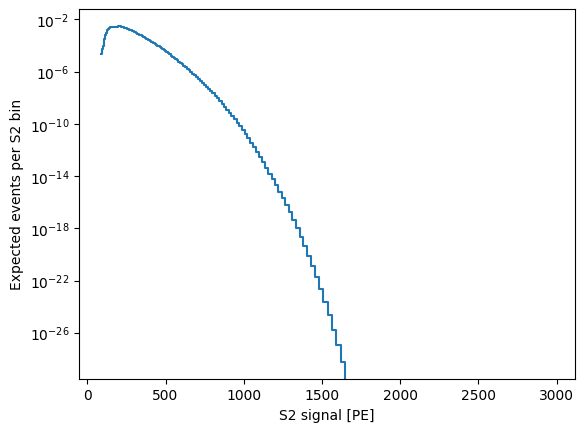

In [52]:
s_i = rate_after_cutoff @ response_matrix_nr
plt.plot(s2_bin_centers_log, s_i,drawstyle = 'steps-mid')
plt.xlabel("S2 signal [PE]")
plt.ylabel("Expected events per S2 bin")
plt.yscale('log')

In [53]:
#The authors of the paper made a cut on the data and what survived are the potential events(which still may include background noise).
#This is what we excract below
k_obs, _ = np.histogram(events['s2_area_pe'].values, bins=s2_bin_edges) #np.histogram returns counts, bin_edges, but we only care about the counts. 
#k_obs[j] is the number of observed events in S2 bin j
#the s2_area_pe is the amount of photoelectron counts per S2 interval(hight x width = Area); they only care about events with S2 area between 90 and 3000PE
#that's where the cut comes from.

In [54]:
#Exctract background info
b_er = bg['er_background_events']
b_cevns = bg['cevns_background_events']
b_nominal = b_er + b_cevns

Now, to implement the likelihood function itself: (note, for the background itself, taken from the report)

\begin{equation}
\ln \mathcal{L}(\mu_s, \beta)
= \sum_{i=1}^{N}
\left[
k_i \ln \mu_i - \mu_i - \ln(k_i!)
\right]
\end{equation}

Where here we'll take just the 

$$\mu_i = \beta \cdot b_i^\mathrm{nom}$$

where $\mu_i$ is the expected value



In [55]:
from scipy.optimize import minimize_scalar
import scipy.stats as stats

# as noted by the function itself, just the background-only likelihood. 
def log_likelihood_bg_only(beta):
    expected = beta * b_nominal 
    return -np.sum(stats.poisson.logpmf(k_obs, expected))  # negative for minimizer

result = minimize_scalar(log_likelihood_bg_only, bounds=(0.1, 30.0), method='bounded')
beta_hat = result.x

#defining the expected value for just the background:
beta_hat_expected = beta_hat * b_nominal.values


Now, first attempt at graphing it

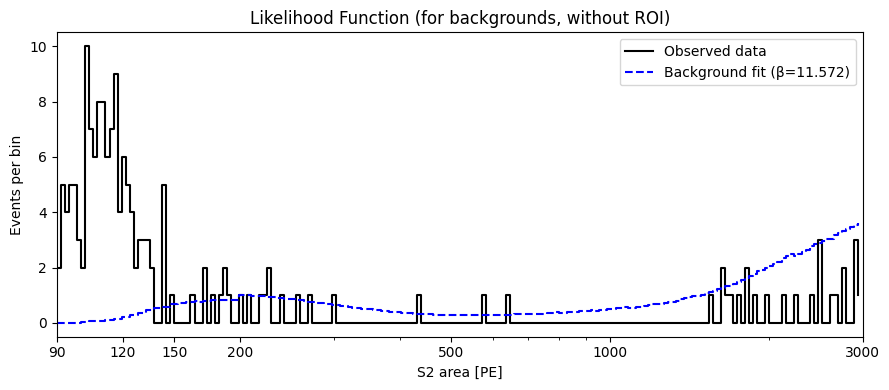

In [56]:
fig, ax = plt.subplots(figsize=(9, 4))

# Observed data as a step histogram
ax.step(s2_bin_edges[:-1], k_obs, where='post', color='black', label='Observed data')

# Background model after fit
ax.step(s2_bin_edges[:-1], beta_hat_expected, where='post', color='blue', 
        linestyle='--', label=f'Background fit (β={beta_hat:.3f})')

ax.set_xscale('log')
ax.set_xlabel('S2 area [PE]')
ax.set_ylabel('Events per bin')
ax.set_xlim(90, 3000)
ax.set_xticks([90, 120, 150, 200, 500, 1000, 3000])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.legend()
plt.title("Likelihood Function (for backgrounds, without ROI)")
plt.tight_layout()
plt.show()

As seen above, even the background data has higher backgrounds past 1000+, due to further discrenpencies muddying up the results. Now, as the original paper implementing a more proper region of interest (for now the original one in the paper, 165.3, 271.7)

Note, this is also a different cut from the earlier energy cut.

In [57]:
roi = (165.3, 271.7) # Implementing the roi, can tweak this to select different parts of the chart seen above
roi_mask = (s2_bin_centers_log >= roi[0]) & (s2_bin_centers_log <= roi[1]) # masks each bin center that is within the roi, by a simple true/false mask.

def log_likelihood_bg_only(beta):
    expected = beta * b_nominal.values[roi_mask]
    return -np.sum(stats.poisson.logpmf(k_obs[roi_mask], expected))
result = minimize_scalar(log_likelihood_bg_only, bounds=(0.1, 30.0), method='bounded') # The bounds here were redone for it to actually find the minimum, since the previous bounds were too narrow.
beta_hat = result.x

#defining the expected value for just the background:
beta_hat_expected = beta_hat * b_nominal.values


Now, plotting the regular poisson: Honestly, will keep this commented, it doesn't really show anything due to the small bin size

In [58]:
# fig, ax = plt.subplots(figsize=(9, 4))

# ax.step(s2_bin_edges[:-1][roi_mask], k_obs[roi_mask], 
#         where='post', color='black', label='Observed data')

# ax.step(s2_bin_edges[:-1][roi_mask], beta_hat * b_nominal.values[roi_mask], 
#         where='post', color='blue', linestyle='--', 
#         label=f'Background fit (β={beta_hat:.3f})')

# ax.set_xscale('log')
# ax.set_xlabel('S2 area [PE]')
# ax.set_ylabel('Events per bin')
# ax.set_xticks([165, 200, 271])
# ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
# ax.legend()
# plt.title("Background fit within ROI [165.3, 271.7] PE")
# plt.tight_layout()
# plt.show()

Note, was just trying to visualize the distribution, more properly, use a log-likelihood function.

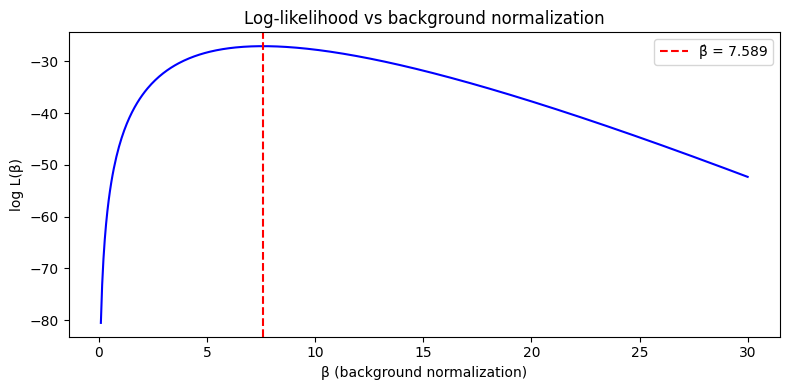

In [59]:
beta_values = np.linspace(0.1, 30.0, 500)
log_likes = [-log_likelihood_bg_only(b) for b in beta_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_values, log_likes, color='blue')
ax.axvline(beta_hat, color='red', linestyle='--', label=f'β̂ = {beta_hat:.3f}')
ax.set_xlabel('β (background normalization)')
ax.set_ylabel('log L(β)')
ax.set_title('Log-likelihood vs background normalization')
ax.legend()
plt.tight_layout()
plt.show()

Then, following the report, to do the Frequentist uncertainty via the curvature, this formula is used:
$$
    \sigma_{\beta} \approx \sqrt{\left( -\frac{d^2 \ln \mathcal{L}}{d\beta^2} \Big|_{\hat{\beta}} \right)^{-1}}
$$

Note, slight tweak, the equation below uses positive, since it was already set to negative earlier


In [60]:
h = 1e-4
f = lambda b: log_likelihood_bg_only(b)
d2 = (f(beta_hat + h) - 2*f(beta_hat) + f(beta_hat - h)) / h**2 # This is the second order differential
sigma_beta = np.sqrt(1.0 / d2)
print(f"beta_hat ± sigma_beta = {beta_hat:.4f} ± {sigma_beta:.4f}")

beta_hat ± sigma_beta = 7.5887 ± 1.8972


In [65]:
print('test for part 3-JamesX')


#We first define the Prior \pi(\beta)
beta_min, beta_max = 0.1, 30.0 #0.1 and 30 because same scale already used
prior_val = 1.0 / (beta_max-beta_min)
print(prior_val)





#Calculate the unnormalized posterior
beta_grid=np.linspace(beta_min,beta_max,1000)
unnormalized_posterior = []
for b in beta_grid:
    log_like=-log_likelihood_bg_only(b) 
    unnormalized_posterior.append(np.exp(log_like)*prior_val)
unnormalized_posterior=np.array(unnormalized_posterior)
evidence=trapezoid(unnormalized_posterior,x=beta_grid)
#We now get the normaised posterior distribution
posterior=unnormalized_posterior/evidence



#We check the uncertainties ----> mean and credible interval which should be (68%)
mean_beta = trapezoid(beta_grid * posterior, x=beta_grid)

print(mean_beta)


test for part 3-JamesX
0.033444816053511704
8.063039527286636
